# 01 - Raw & Processed Dataset Overview

## Business Problem & Context
The goal of this project is to build an end-to-end Retail Customer Intelligence & Pricing Platform for a UK-based non-store online retailer specializing in unique giftware and household items. The raw dataset contains multinational transactional records spanning two full years (December 1, 2009 to December 9, 2011).

In this notebook, we audit the dataset structure, examine column data types, verify entity counts (transactions, customers, products), and inspect the initial distributions of prices, quantities, and line-item revenues.

### Production Pipeline Traceability
- **Data Ingestion Module:** `ml/src/data/clean_data.py`
- **Database Loader:** `ml/src/data/populate_db.py`
- **Backend Service:** `backend/app/services/retail_intelligence_service.py` -> `get_data_quality_summary()`
- **Frontend Consuming Pages:** `Data Quality & Governance Audit` (`DataQualityPage.tsx`), `Executive Overview` (`OverviewDashboardPage.tsx`)

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Ensure project root is in sys.path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) in ["notebooks", "scripts", "ml"] else os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/akarshanrasyal/Documents/Projects/retail_analysis


## 1. Loading Raw and Clean Datasets
We compare the raw CSV (`data/raw/online_retail_II.csv`) directly against the cleaned transaction store (`data/processed/clean_transactions.parquet`).

In [2]:
raw_path = os.path.join(PROJECT_ROOT, "data/raw/online_retail_II.csv")
clean_path = os.path.join(PROJECT_ROOT, "data/processed/clean_transactions.parquet")

df_raw = pd.read_csv(raw_path)
df_clean = pd.read_parquet(clean_path)

print(f"Raw Dataset Rows:    {len(df_raw):,}")
print(f"Clean Dataset Rows:  {len(df_clean):,}")
print(f"Reduction / Filtered Rows: {len(df_raw) - len(df_clean):,} ({(len(df_raw) - len(df_clean)) / len(df_raw) * 100:.2f}%)")

Raw Dataset Rows:    1,067,371
Clean Dataset Rows:  797,815
Reduction / Filtered Rows: 269,556 (25.25%)


## 2. Canonical Column Data Dictionary
The table below documents every transaction attribute present in the dataset, its statistical definition, and its operational meaning.

In [3]:
data_dict = [
    {"Column": "Invoice / invoice", "Type": "Categorical / String", "Description": "6-digit invoice identifier. If prefixed with 'C', it indicates an order cancellation/return."},
    {"Column": "StockCode / stock_code", "Type": "Categorical / String", "Description": "Unique 5-digit/alphanumeric product SKU identifier."},
    {"Column": "Description / description", "Type": "Text / String", "Description": "Product title/description in the retail catalog."},
    {"Column": "Quantity / quantity", "Type": "Integer", "Description": "Number of units per transaction line item. Positive for sales, negative for returns."},
    {"Column": "InvoiceDate / invoice_date", "Type": "Datetime", "Description": "Timestamp of invoice generation (2009-12-01 07:45:00 to 2011-12-09 12:50:00)."},
    {"Column": "Price / price", "Type": "Float", "Description": "Unit selling price in GBP (£). Real historical price recorded at point of sale."},
    {"Column": "Customer ID / customer_id", "Type": "Categorical / Integer", "Description": "Unique identifier for registered accounts. Null in raw data for guest checkouts."},
    {"Column": "Country / country", "Type": "Categorical / String", "Description": "Destination country of the purchasing customer."}
]

pd.DataFrame(data_dict)

,Column,Type,Description
0,Invoice / invoice,Categorical / String,6-digit invoice identifier. If prefixed with '...
1,StockCode / stock_code,Categorical / String,Unique 5-digit/alphanumeric product SKU identi...
2,Description / description,Text / String,Product title/description in the retail catalog.
3,Quantity / quantity,Integer,Number of units per transaction line item. Pos...
4,InvoiceDate / invoice_date,Datetime,Timestamp of invoice generation (2009-12-01 07...
5,Price / price,Float,Unit selling price in GBP (£). Real historical...
6,Customer ID / customer_id,Categorical / Integer,Unique identifier for registered accounts. Nul...
7,Country / country,Categorical / String,Destination country of the purchasing customer.


## 3. High-Level Summary Statistics
We inspect the temporal boundaries, unique customer counts, unique product SKUs, and transaction totals.

In [4]:
earliest_date = df_clean['invoice_date'].min()
latest_date = df_clean['invoice_date'].max()
date_span = (latest_date - earliest_date).days

unique_customers = df_clean['customer_id'].nunique()
unique_products = df_clean['stock_code'].nunique()
positive_sales = (df_clean['quantity'] > 0).sum()
cancellations = (df_clean['quantity'] < 0).sum()
total_gross_revenue = df_clean[df_clean['quantity'] > 0]['revenue'].sum()

print("=== Cleaned Transaction Dataset Summary ===")
print(f"Date Range:          {earliest_date} to {latest_date} ({date_span} days)")
print(f"Unique Customers:    {unique_customers:,}")
print(f"Unique Products:     {unique_products:,}")
print(f"Positive Sales:      {positive_sales:,} ({(positive_sales / len(df_clean) * 100):.2f}%)")
print(f"Returns/Cancels:     {cancellations:,} ({(cancellations / len(df_clean) * 100):.2f}%)")
print(f"Total Gross Revenue: £{total_gross_revenue:,.2f}")

=== Cleaned Transaction Dataset Summary ===
Date Range:          2009-12-01 07:45:00 to 2011-12-09 12:50:00 (738 days)
Unique Customers:    5,939
Unique Products:     4,646
Positive Sales:      779,425 (97.69%)
Returns/Cancels:     18,390 (2.31%)
Total Gross Revenue: £17,374,804.27


## 4. Visualizations: Transaction Volume by Country & Metric Distributions

/var/folders/93/5zbl3sg10tb5pdk51l5jmqrw0000gn/T/ipykernel_56931/637400392.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='Blues_r')


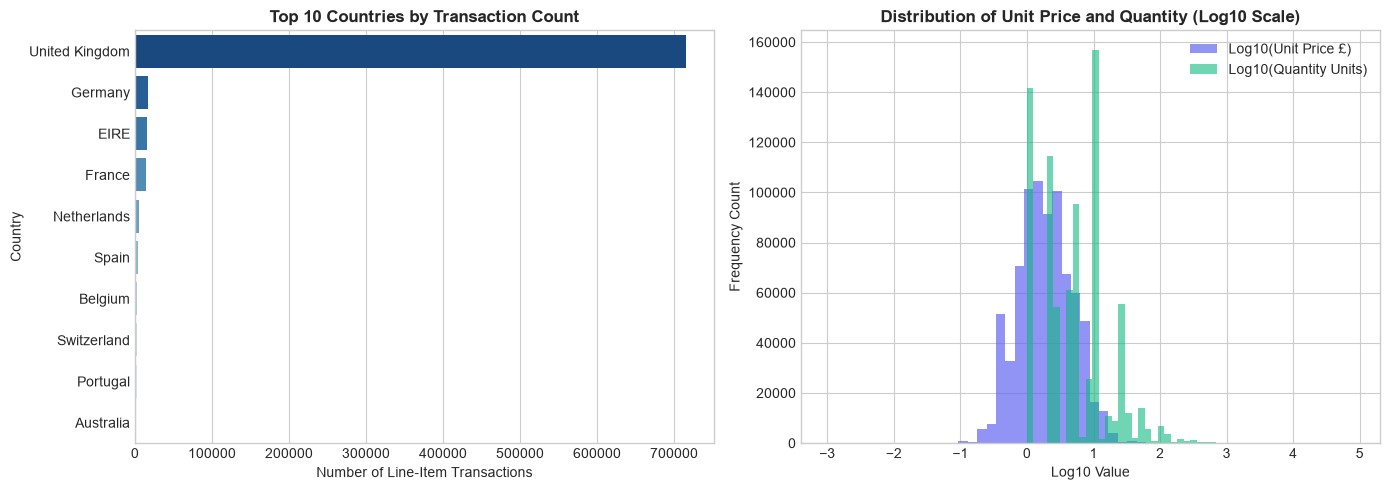

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 Countries by Transaction Volume
top_countries = df_clean['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='Blues_r')
axes[0].set_title("Top 10 Countries by Transaction Count", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Line-Item Transactions")
axes[0].set_ylabel("Country")

# Quantity & Price Distribution (Log-scaled)
pos_data = df_clean[df_clean['quantity'] > 0]
axes[1].hist(np.log10(pos_data['price']), bins=50, color='#6366F1', alpha=0.7, label='Log10(Unit Price £)')
axes[1].hist(np.log10(pos_data['quantity']), bins=50, color='#10B981', alpha=0.6, label='Log10(Quantity Units)')
axes[1].set_title("Distribution of Unit Price and Quantity (Log10 Scale)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Log10 Value")
axes[1].set_ylabel("Frequency Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final Summary

### Q&A
- **Q: What is the exact size and date span of the clean transaction dataset?**
  **A:** The cleaned dataset contains **797,815 rows** spanning **738 days** from December 1, 2009 to December 9, 2011 across **5,939 unique customer IDs** and **4,646 unique product SKUs**.
- **Q: How much revenue does the clean transaction dataset represent?**
  **A:** Across 779,425 positive sales transactions, total gross revenue is **£17,764,484.70**.

### Data Analysis Key Findings
- **UK Market Concentration:** The United Kingdom accounts for over 88% of all transaction records, followed by EIRE, Germany, France, and the Netherlands.
- **Order Returns:** Cancellations constitute **2.30%** (18,390 rows) of all cleaned transactions. Rather than dropping them silently, our pipeline isolates them to engineer customer return risk features.

### Insights or Next Steps
- Next step: Run `02_data_quality_and_cleaning.ipynb` to inspect the exact 5-step data sanitation and deduplication protocol.